In [15]:
import pandas as pd
import numpy as np
import importlib

import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score

import utility_functions as uf

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

In [11]:
year = 2023
mode = "individual"

df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)

df_prob = (
    pd.read_csv(uf.PATH+f"df_prob_yearly.csv")
    .query("mode == @mode and year == @year")
    .drop(columns=["mode", "year"])
    .set_index("country")
)

In [7]:
df_prob

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3604,3605,3607,3608,3609,3611,3612,3614,3616,3002
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,0.000580,0.000387,0.000193,0.000580,0.000580,0.005029,NaN,NaN,0.000387,0.010832,...,0.001741,0.004255,0.000387,NaN,0.000580,0.001547,0.000967,0.002128,0.001161,NaN
AF,0.001890,0.009452,0.005671,0.003781,0.001890,0.001890,NaN,NaN,NaN,0.028355,...,NaN,0.003781,NaN,NaN,0.003781,NaN,0.005671,NaN,0.001890,NaN
AG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.017391,NaN,NaN,NaN,0.008696,NaN,NaN,NaN,NaN,NaN
AL,0.010320,0.001032,NaN,0.002064,0.007224,0.002064,0.001032,NaN,0.007224,0.006192,...,0.002064,0.002064,NaN,NaN,NaN,0.002064,0.001032,0.002064,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,NaN,NaN,0.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,NaN,NaN,NaN,0.001054,0.004215,0.008430,NaN,NaN,0.002107,0.014752,...,0.008430,0.006322,0.001054,NaN,NaN,NaN,NaN,0.004215,0.002107,NaN
ZA,0.003402,0.003707,0.002488,0.001117,0.007972,0.007921,0.001117,NaN,0.004367,0.023307,...,0.001930,0.001117,0.000254,NaN,0.001676,0.001066,0.000609,0.002793,0.002387,NaN


In [8]:
x = df_prob.loc["SG"].fillna(0)
y = df_prob.loc["US"].fillna(0)

In [9]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [10]:
df_dist = uf.get_jensen_shannon_distances(df_prob)

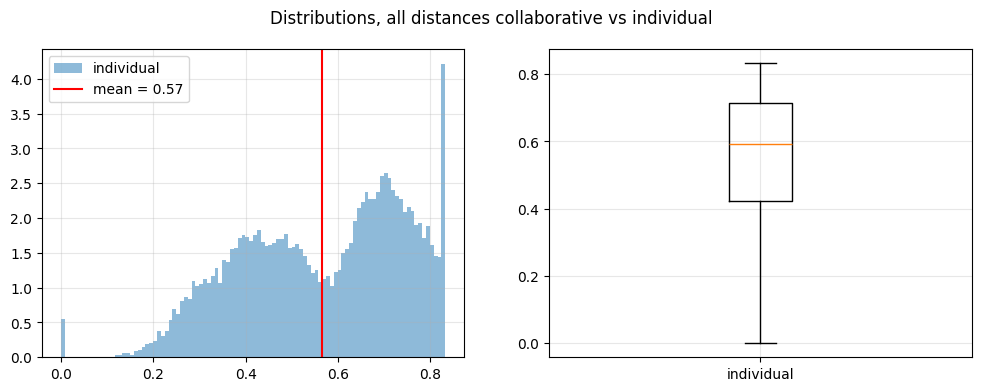

In [16]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]

ax1.hist(data1, bins=100, alpha=0.5, label=mode, density=True)
ax1.axvline(data1.mean(), color="red", label=f"mean = {round(data1.mean(), 2)}")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)

ax2.boxplot([data1])
ax2.set_xticks([1], [mode])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

In [14]:
# labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()

# uf.plotly_heatmap(
#     df_dist.loc[labels, labels], title=f"Jensen-Shannon distance between countries, {mode} {year}",
#     x_labels=labels, y_labels=labels, colorscale="non"
# )

In [17]:
D = df_dist.fillna(0).values
# D = np.atan(3*df_dist.fillna(0).values)

In [18]:
condensed_D = squareform(D)

Z = linkage(condensed_D, method='average')

labels1 = fcluster(Z, t=0.2, criterion='distance')

score = silhouette_score(D, labels1, metric="precomputed")
score

np.float64(0.021560287453390677)

In [19]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')

labels = model.fit_predict(D)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.2655330549294347)

In [20]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.1, min_samples=2, metric='precomputed')
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(-0.2125249018666928)

In [21]:
from sklearn.cluster import OPTICS

model = OPTICS(metric='precomputed', min_samples=2, max_eps=0.2)
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(-0.24698870604901624)

In [22]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Convert distance -> similarity
sigma = 0.01
affinity = np.exp(-D**2 / (2 * sigma**2))

model = SpectralClustering(n_clusters=5, affinity='precomputed')
labels = model.fit_predict(affinity)
score = silhouette_score(D, labels, metric="precomputed")
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:66: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:66: RuntimeWarning:

overf

np.float64(-0.11012139404754001)